# Eingangssignale: Wellen und Stimmen

Ausgangspunkt aller Audioverarbeitung ist das gemessene Mikrofonsignal. Das kann eine Wave-Datei oder die Ausgabe eines Mikrofontreibers sein.
Im Luftmedium sind Audiosignale Änderungen von Druck und Geschwindigkeit. Diese Änderungen nehmen Mikrofone oder das menschliche Ohr auf.
Bevor die digitale Signalverarbeitung beginnt, wird das Mikrofonsignal $x(t)$ vom Analogen ins Digitale über einen Analog-Digital-Wandler (ADC) gebracht.
Der ADC lässt sich durch drei Parameter beschreiben:

1) Übersteuerungspunkt $A$: die maximale analoge Amplitude, die ohne Verzerrung digitalisiert werden kann. Werden Werte über $A$ gemessen, kommt es zum Clipping. Nach der Quantisierung liegen alle Werte von $x(t)$ im Bereich $-A..A$.
2) Abtastrate $r$: die Abtastrate gibt an, wie viele Samples pro Sekunde gemessen werden. In der Audiotechnik sind übliche Raten $r=44100$ Hz (Audio-CD), $r=48000$ Hz (professionelle Geräte), $r=16000$ Hz (Weitband-Audio) oder $r=8000$ Hz (Schmalband-Audio). Die Inverse der Abtastrate ist die Abtastdauer $T=\frac{1}{r}$, also der zeitliche Abstand zwischen zwei Samples.
3) Bitbreite $w$: die Quantisierung verwendet eine bestimmte Anzahl Bits pro Sample. Damit sind $2^w$ verschiedene Quantisierungsstufen möglich. Das führt zu einem Quantisierungsschritt $\Delta=\frac{2A}{2^w}$.

Das Produkt aus Abtastrate $r$ und Bitbreite $w$ ergibt die Datenmenge pro Audiokanal und Sekunde.

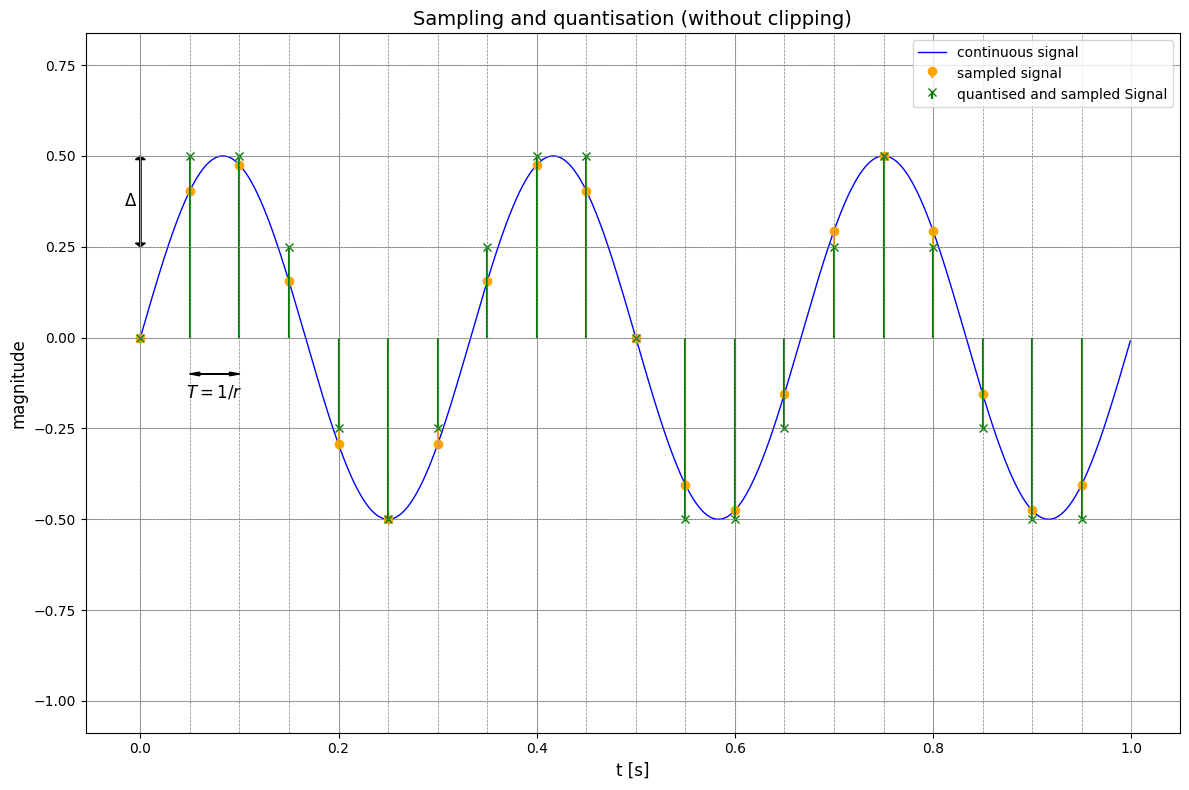

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def CreatePlot(A, fs_cont, t_cont, signal_cont, title="Sampling and quantisation (without clipping)"):
    r = 20  # low sampling rate for visualizing sampling and quantisation
    SamplingFactor = int(fs_cont / r)
    t_sampled = t_cont[::SamplingFactor]
    signal_sampled = signal_cont[::SamplingFactor]

    w = 3
    quantization_levels = 2**w  # Anzahl der Quantisierungsstufen
    delta = (2*A) / quantization_levels
    #signal_quantized = np.round(signal_sampled * (quantization_levels / 2)) / (quantization_levels / 2)
    signal_quantized = np.round(signal_sampled / delta)
    signal_quantized = np.minimum(signal_quantized, quantization_levels // 2 - 1)  # Clip to max level
    signal_quantized = np.maximum(signal_quantized, -quantization_levels // 2)  # Clip to min level
    signal_quantized = signal_quantized * delta

    plt.figure(figsize=(12, 8))
    plt.plot(t_cont, signal_cont, label="continuous signal", color="blue", linewidth=1)
    plt.stem(t_sampled, signal_sampled, linefmt="orange", markerfmt="o", basefmt=" ", label="sampled signal")
    plt.stem(t_sampled, signal_quantized, linefmt="green", markerfmt="x", basefmt=" ", label="quantised and sampled Signal")

    # mark all quantisation intervals
    for t in t_sampled:
        plt.axvline(x=t, color='gray', linestyle='--', linewidth=0.5)
    value = -A
    while value < A:
        plt.axhline(value, color='gray', linestyle='--', linewidth=0.5)
        value += delta

    # plot quantisation level Δ
    plt.arrow(0, delta, 0, delta, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.arrow(0, 2*delta, 0, -delta, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.text(-0.01, 1.5*delta, r"$\Delta$", ha="center", va="center", fontsize=12, color="black")
    # plotting of sampling rate and sampling duration
    plt.arrow(1/r, -0.1, 1/r, 0, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.arrow(2/r, -0.1, -1/r, 0, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.text(1.5/r, -0.15, r"$T=1/r$", ha="center", va="center", fontsize=12, color="black")

    plt.title(title, fontsize=14)
    plt.xlabel("t [s]", fontsize=12)
    plt.ylabel("magnitude", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

A = 1.0  # overload point
f = 3  # frequency of the sinusoidal signal
fs_cont = 1000  # high sampling rate for continuous signal
t_cont = np.linspace(0, 1, fs_cont, endpoint=False)
signal_cont = 0.5*A*np.sin(2 * np.pi * f * t_cont)
CreatePlot(A, fs_cont, t_cont, signal_cont)


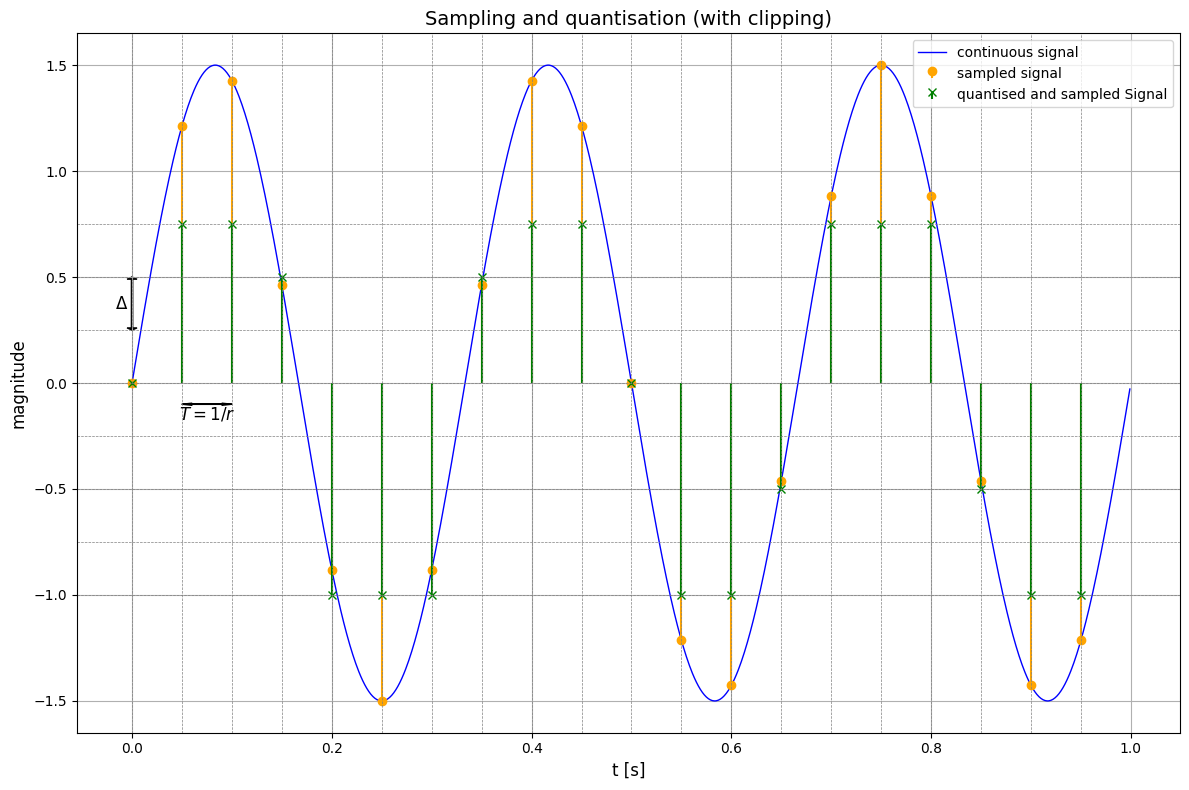

In [2]:
signal_cont = 1.5*A*np.sin(2 * np.pi * f * t_cont)
CreatePlot(A, fs_cont, t_cont, signal_cont, title="Sampling and quantisation (with clipping)")

## Abtasttheorem

Das Abtasttheorem besagt, dass die höchste Frequenz $f_c$ des zeitkontinuierlichen Signals $x(t)$ höchstens halb so groß wie die Abtastrate sein darf:

$f_c \leq \frac{1}{2T} = \frac{r}{2}$

Wenn dieses Theorem verletzt wird, spricht man von Alias.

Im Folgenden wird das kontinuierliche Signal abgetastet und anschließend anhand der Samples rekonstruiert. Für Audiosignale übernimmt ein idealer Tiefpass die Interpolation.

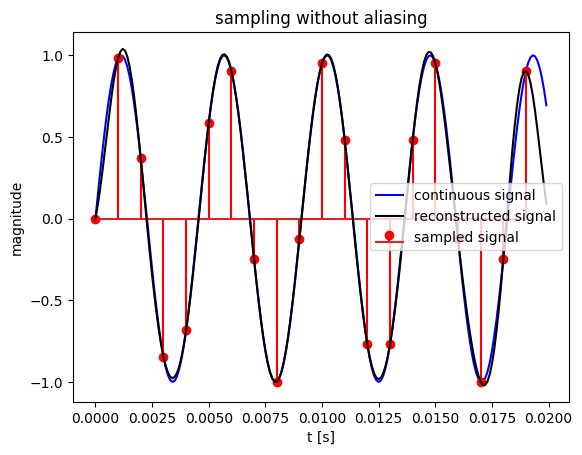

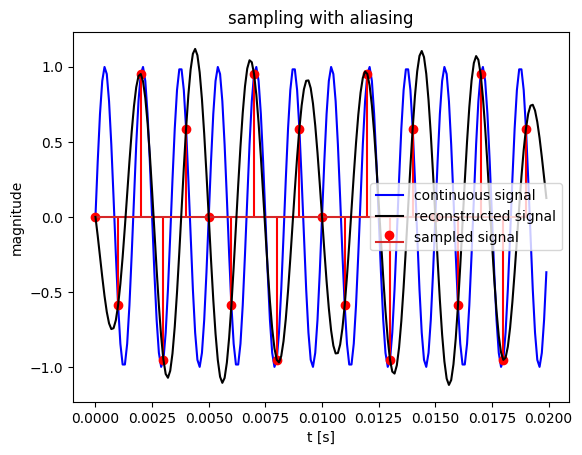

In [3]:
def TimeContinuousFunction(t, FrequencyInHertz = 220):
    return np.sin(2*np.pi*FrequencyInHertz*t)

def InterpolationFilter(x):
    return np.sinc(x)

def ReconstructedSignal(s_a, t, r, InterpolationFilterFunctionPointer = InterpolationFilter):
    s_tilde = np.zeros(t.shape)
    for n in range(s_a.shape[0]):
        h = InterpolationFilterFunctionPointer(t*r - n)
        s_tilde += s_a[n] * h
    return s_tilde

r = 1000 # samplerate in Hertz
UpsamplingFactor = 10
t = np.arange(200)/(UpsamplingFactor*r) # simulation of time continuous function by ten times faster sampling
s = TimeContinuousFunction(t)

t_a = t[0::UpsamplingFactor]
s_a = TimeContinuousFunction(t_a)

plt.plot(t  , s  , 'b', label='continuous signal')
plt.stem(t_a, s_a, 'r', label='sampled signal')
plt.plot(t, ReconstructedSignal(s_a, t, r), 'k', label='reconstructed signal')
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.title('sampling without aliasing')
plt.legend()
plt.show()

FrequencyInHertz = 600
t = np.arange(200)/(UpsamplingFactor*r)
s = TimeContinuousFunction(t, FrequencyInHertz)
s_a = TimeContinuousFunction(t_a, FrequencyInHertz)
plt.plot(t  , s  , 'b', label='continuous signal')
plt.stem(t_a, s_a, 'r', label='sampled signal')
plt.plot(t, ReconstructedSignal(s_a, t, r), 'k', label='reconstructed signal')
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.title('sampling with aliasing')
plt.legend()
plt.show()

## Downsampling
Das Abtasttheorem fordert für aliasfreie Signale: $T=1/r$

$f_c \leq \frac{1}{2T}$

Wir setzen voraus, dass die höchste Frequenz $f_c$ von $x(n)$ deutlich kleiner als die halbe Abtastrate ist:

$f_c \ll \frac{1}{2T}$ 

Dann lässt sich die Abtastrate $r=\frac{1}{T}$ um einen Faktor $N$ reduzieren:

$N\cdot f_c \leq \frac{1}{2T}$

$\rightarrow N\leq \frac{1}{2Tf_c}=\frac{r}{2f_c}$

Diese Verringerung heißt Downsampling. Für ganzzahliges $N$ ist der Algorithmus sehr einfach:

$x_\\text{downsampled}(n)=x\left(N\cdot n\right)$

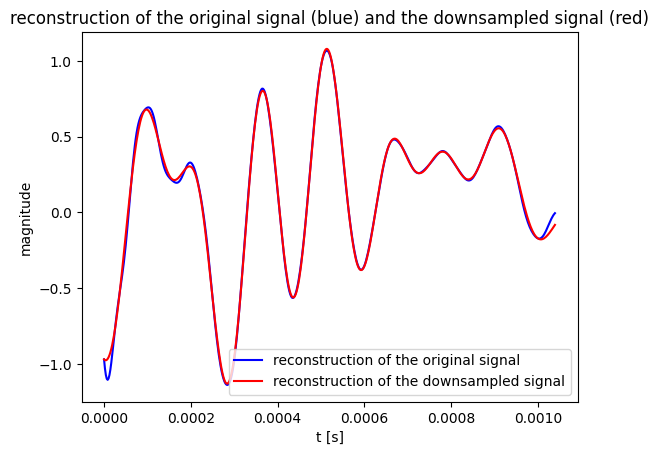

SNR =  26.611068969886098  dB


In [4]:
r = 48000
x = np.random.randn(50)
fc = 8000
t = np.arange(x.shape[0]) / r
y = np.zeros(x.shape)
for n in range(x.shape[0]):    
    y += x[n] * np.sinc(2*fc*(t - n/r)) * 2 * fc / r

N = 10
t = np.arange(y.shape[0] * N) / (r*N)
z1 = ReconstructedSignal(y, t, r)
DownSamplingFactor = r // (2*fc)

y_Downsampled = y[0::DownSamplingFactor]
z2 = ReconstructedSignal(y_Downsampled, t, r / DownSamplingFactor)
plt.plot(t, z1, 'b', label='reconstruction of the original signal')
plt.plot(t, z2, 'r', label='reconstruction of the downsampled signal')
plt.title('reconstruction of the original signal (blue) and the downsampled signal (red)')
plt.legend()
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.show()
SNR = 10*np.log10(np.sum(z1**2) / np.sum((z1-z2)**2))
print('SNR = ', SNR, ' dB')

## Logarithmische Pegel

Im Folgenden werden zwei logarithmische Pegel eingeführt: dB SPL der analogen Welt (bezogen auf physikalischen Schalldruck) und dB FS der digitalen Welt (bezogen auf den Übersteuerungspunkt).

### dB Schalldruckpegel

Das menschliche Ohr kann einen großen Schalldruckbereich analysieren. Deshalb wird der Pegel üblicherweise logarithmisch angegeben, z. B. dB SPL (Sound Pressure Level):

$L=20\log_{10}\frac{p_\\text{eff}}{20\\mu\\text{Pa}}$ dB SPL

Dabei entspricht $p_\\text{eff}$ dem [RMS] des Schalldrucks.
$0$ dB SPL ist ein ruhiges Schlafzimmer, in dem nichts zu hören ist. $140$ dB SPL entspricht einem startenden Jet.

### dB Full Scale
dB FS wird auf die maximal mögliche Amplitude eines digitalen Signals normiert. Angenommen, die maximale Amplitude ist $A$ (typischerweise der Übersteuerungspunkt im digitalen Bereich). Eine Sinusschwingung mit Amplitude $A$ hat einen [RMS] von $\frac{A}{\sqrt{2}}$ und eine [Leistung] von $P=\frac{A^2}{2}$. Diese Sinus ist als $0$ dB FS definiert. Ein beliebiges Signal $x(n)$ mit der Leistung

$P=\frac{1}{N}\sum_{n=0}^{N-1}x^2(n)$

hat den [Pegel]

$L=10\log_{10}\frac{P}{\frac{A^2}{2}}\text{ dB FS}=10\log_{10}\frac{2\cdot P}{A^2}\text{ dB FS}$

Die digitale Ausgabe eines AD-Wandlers wird üblicherweise auf eine maximale Amplitude von $A=1$ normiert.

### Kalibrierung

Die Kalibrierung erfolgt durch Messung von dB SPL im physikalischen Bereich und dB FS im digitalen Bereich desselben Signals. Die Kalibrierung lässt sich durch einen Parameter $a$ beschreiben:

$L_\\text{dB FS} = a + L_\\text{dB SPL}$

Beispielsweise hat das Smartphone des Dozenten einen Kalibrierungsfaktor von etwa $a\approx115$ dB (gemessen im Januar 2023).

## Quantisierungsrauschen

Digitale Werte werden aufgrund der Quantisierung mit begrenzter Auflösung gespeichert. Auf der niedrigsten Ebene entspricht das der Rundung kontinuierlicher Werte auf diskrete Stufen mit einer Bitbreite $w$. Diese Rundung kann als zusätzliches Rauschen interpretiert werden, wenn drei Bedingungen erfüllt sind:

1) Das Signal besitzt eine deutlich höhere Leistung als das Quantisierungsrauschen.
2) Die Signal-Frequenz ist hoch genug, sodass benachbarte Werte statistisch unabhängige Quantisierungsrauschen haben.
3) Das Signal ist nicht periodisch mit einer Periodenlänge $T_0=\frac{n}{r}$, wobei $n$ eine ganze Zahl ist.

- Für Bedingung 1) sollte die Sensorempfindlichkeit so hoch sein, dass das Signal auf einem sinnvollen Pegel in dB FS aufgenommen wird.
- Bedingung 2) ist für Audio kein Problem, da Frequenzen unter etwa 16 Hz für Menschen unhörbar sind. Diese sehr tiefen Frequenzen können daher ohne Informationsverlust gefiltert werden.
- Bedingung 3) ist nur bei künstlichen Testsignalen relevant (z. B. ein 1 kHz Sinus). In realen Aufnahmen enthält das Eingangssignal viele Frequenzen.

Sind die Bedingungen 1) bis 3) erfüllt, lässt sich das Quantisierungsrauschen für $w$ Bits als weißes Rauschen mit der Leistung

$P_E=\frac{\Delta^2}{12}$

interpretieren, mit

$\Delta=\frac{2A}{2^w}$

## Dithering
Wenn mindestens eine der drei Bedingungen für die weiße-Rausch-Annäherung nicht erfüllt ist, sollte nach der Analog-Digital-Umwandlung Dithering angewendet werden:

Dithering fügt dem Signal zufälliges Rauschen auf dem Niveau des niedrigsten Bits hinzu.
Dadurch wird das Quantisierungsrauschen wieder weiß.

In [5]:
r = 48000
w = 8
factor = 2**(w-1) # one bit is reserved for the sign
f = 1000
t = np.arange(r) / r
x = np.sin(2*np.pi*f*t) # periodic signal with a period length of 1 ms, violating the condition 3)
x_quantised =np.round(x*factor) / factor
DitheringNoise = (np.random.rand(x.shape[0]) - 0.5) / factor # dithering noise at the lowest bit
y = x_quantised + DitheringNoise
y_quantised = np.round(y*factor) / factor
ErrorByDithering = np.sum((x_quantised - y_quantised)**2)
print('Error due to dithering: ', ErrorByDithering)

Error due to dithering:  0.0


## Programmieraufgabe:

Vervollständige den fehlenden Code in den folgenden Prozeduren:

1) EvaluatePowerOfSignal

2) EvaluateSNROfQuantization

3) EvaluateSNR

4) EvaluatedBFullScale

5) EvaluatedBSoundPressureLevel

In [6]:
import unittest

def EvaluatePowerOfSignal(x):
    
    return P_S

def EvaluateSNROfQuantization(w):
    A = 1.0
    x = np.random.rand(10000) * 2 * A - A

    SNR = 10*np.log10(P_S / P_N)
    return SNR

def EvaluateSNR(x, y):

    return SNR

def EvaluatedBFullScale(A, x):

    return L_dBFS

def EvaluatedBSoundPressureLevel(x_inPascal):

    return L_SPL

class TestProgrammingExercise(unittest.TestCase):

    def test_SNRMonotonicallyIncreasing(self):
        w1 = np.random.randint(20)
        w2 = w1 + 1
        self.assertGreater(EvaluateSNROfQuantization(w2), EvaluateSNROfQuantization(w1))
    
    def test_SNRSlope(self):
        for w in range(16):
            self.assertAlmostEqual(EvaluateSNROfQuantization(w), w*6, delta = 0.5)
            
    def test_EvaluatedBFullScale(self):
        A = np.random.rand(1)
        x = A*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatedBFullScale(A, x), 0.0, delta = 0.5)
        self.assertAlmostEqual(EvaluatedBFullScale(A, x/np.sqrt(2)), -3.0, delta = 0.5)
        
    def test_EvaluatedBSoundPressureLevel(self):
        a = np.random.rand(1)
        x_inPascal = a*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatedBSoundPressureLevel(x_inPascal), 20*np.log10(a) + 90.969, delta = 0.5)
        
    def test_EvaluatePowerOfSignalSinus(self):
        A = np.random.rand(1)
        x = A*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), A**2/2, delta = 0.01)

    def test_EvaluatePowerOfSignalUniformNoise(self):
        A = np.random.rand(1)
        x = 2*A*np.random.rand(10000)-A
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), (2*A)**2/12, delta = 0.01)
        
    def test_EvaluatePowerOfSignalGaussianNoise(self):
        s = np.random.rand(1)
        x = s*np.random.randn(10000)
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), s**2, delta = 0.1)
        
    def test_EvaluateSNRErrorEqualSignal(self):
        x = np.random.randn(10000)
        e = np.random.randn(10000)
        y = x + e
        self.assertAlmostEqual(EvaluateSNR(x, y), 0.0, delta = 0.5)
        
    def test_EvaluateSNRSmallError(self):
        factor = 1e-3
        x = np.random.randn(10000)
        e = np.random.randn(10000) * factor
        y = x + e
        self.assertAlmostEqual(EvaluateSNR(x, y), -20*np.log10(factor), delta = 3.0)

# https://stackoverflow.com/questions/40172281/unit-tests-for-functions-in-a-jupyter-notebook
unittest.main(argv=[''], verbosity=2, exit=False)

test_EvaluatePowerOfSignalGaussianNoise (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalGaussianNoise) ... ok


test_EvaluatePowerOfSignalSinus (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalSinus) ... ok
test_EvaluatePowerOfSignalUniformNoise (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalUniformNoise) ... ok
test_EvaluateSNRErrorEqualSignal (__main__.TestProgrammingExercise.test_EvaluateSNRErrorEqualSignal) ... ok
test_EvaluateSNRSmallError (__main__.TestProgrammingExercise.test_EvaluateSNRSmallError) ... ok
test_EvaluatedBFullScale (__main__.TestProgrammingExercise.test_EvaluatedBFullScale) ... ok
test_EvaluatedBSoundPressureLevel (__main__.TestProgrammingExercise.test_EvaluatedBSoundPressureLevel) ... ok
test_SNRMonotonicallyIncreasing (__main__.TestProgrammingExercise.test_SNRMonotonicallyIncreasing) ... ok
test_SNRSlope (__main__.TestProgrammingExercise.test_SNRSlope) ... ok

----------------------------------------------------------------------
Ran 9 tests in 0.034s

OK


## Klausurvorbereitung

1) Ein Quantisierer mit $w=16$ Bit wird verwendet. Bestimme die Datenmenge für 70 Minuten Aufnahme auf einer Audio-CD. Hinweis: Audio-CDs werden im Stereo-Modus aufgezeichnet.

2) Bestimme den Pegel in dB SPL eines Sinus mit Amplitude $0,1$ Pa. Dieser Sinus wird zu $x(n)=0.25\cdot\sin\left(2\pi f\frac{n}{r}\right)$ digitalisiert. Der maximale Betrag des AD-Wandlers ist $A=1,0$. Bestimme den dazugehörigen Pegel in dB FS und den Kalibrierungsfaktor $a$.

3) Berechne das SNR für ein Signal mit -12 dB FS bei Quantisierungsrauschen für $w=16$ Bit. $A=1,0$ bleibt gültig.

4) Gegeben ist $x(t)=a\cdot\cos\left(2\pi ft\right)$ mit $f=2$ kHz. $x(t)$ hat einen Pegel von 75 dB SPL. Berechne den Parameter $a$. Lässt sich anhand der Angaben das Vorzeichen von $a$ bestimmen? Bestimme den Pegel in dB SPL, wenn die Frequenz verdoppelt wird.

5) Welche Art von Funktion $y=f(x)$ ergibt bei logarithmischer x-Achse, logarithmischer y-Achse und logarithmisch-logarithmischem Plot jeweils eine Gerade?

6) Ein Signal hat einen Kalibrierungsfaktor von $a=-120$ dB. Bestimme den Übersteuerungspunkt in dB SPL. Gehe von einem Sinus aus.

7) Bestimme den Pegel des Quantisierungsrauschens in dB FS für $w=16$ Bit.

8) Gib die mathematische Beschreibung eines digitalen Signals an, das dem maximal möglichen Pegel in dB FS entspricht. Wie hoch ist dieser Pegel?

9) Ein zeitkontinuierliches Signal $x(t)=\cos\left(7\cdot t\right)^2$ wird mit $r=10$ Hz abgetastet. Bestimme die ersten fünf Samples.

10) Ein zeitdiskretes Signal mit $r=32$ kHz wird durch einen Tiefpass mit Grenzfrequenz $f_c=3400$ Hz gefiltert. Wie hoch muss die Abtastrate nach dem Tiefpass mindestens sein? Welcher maximale ganzzahlige Downsamplingfaktor ist erlaubt? Entspricht das Signal nach dem Tiefpass Breitband- oder Schmalband-Sprache?

11) Ein Mikrofonsignal $y(n)$ wird mit $r=48$ kHz aufgenommen. Anschließend wird $y(n)$ durch einen Bandpass $h(n)$ mit Grenzfrequenzen $f_1=100$ Hz und $f_2=7000$ Hz gefiltert: $z(n)=h(n)*y(n)$. Hat $z(n)$ eine Gleichanteilskomponente? Sind menschliche Stimmen in $z(n)$ verständlich? Was sind die höchsten Frequenzen in $y(n)$ und $z(n)$?

12) Ein Signal $x(t)=\cos^2(500\cdot t)$ wird mit $r=200$ Hz abgetastet. Führt diese Abtastung zu Alias-Effekten?

## Zusammenfassung

Nach der Arbeit mit diesem Jupyter Notebook solltest du folgende Themen erklären können:

- In welchen Fällen ist der Übersteuerungspunkt $A$ für deine Messung relevant?
- Wann ist die Bitbreite $w$ relevant für deine Messung?
- Wann ist die Abtastrate $r$ relevant?
- Was besagt das Abtasttheorem?
- Was ist Aliasing?
- Worin besteht der Unterschied zwischen dB SPL und dB FS?
- Wann möchtest du Dithering einsetzen?
- Wie beeinflusst das Quantisierungsrauschen deine Messung?